# Weather Prediction Project (Foundation of Data Science Lab)

### Name of Dataset:
- `weather_prediction_dataset.csv` 
- `weather_prediction_bbq_labels.csv`

### Team Members:
- Pragyan Raj Niroula
- Pratyush Budhathoki

### Roll No:
- 054 and 060


## 1. Problem Definition

The goal of this project is to build weather prediction models using real-world data.

We solve two tasks:
1. **Regression task**: Predict `BASEL_temp_max` (maximum temperature).
2. **Classification task**: Predict `BASEL_BBQ_weather` (BBQ-friendly day: 1/0).

Model choices:
- **Linear Regression** for continuous temperature prediction.
- **Logistic Regression** for binary weather classification.


In [12]:
# 2. Import Libraries
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    mean_squared_error,
    precision_score,
    r2_score,
    recall_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

sns.set_theme(style='whitegrid')


## 2. Data Collection

The dataset is downloaded from Kaggle and stored in:
- `kaggle_similar_weather/weather_prediction_dataset.csv`
- `kaggle_similar_weather/weather_prediction_bbq_labels.csv`

The first file contains weather features across multiple cities. The second file contains BBQ-weather labels.


In [13]:
# Load and combine datasets
weather_path = 'kaggle_similar_weather/weather_prediction_dataset.csv'
labels_path = 'kaggle_similar_weather/weather_prediction_bbq_labels.csv'

weather_df = pd.read_csv(weather_path)
labels_df = pd.read_csv(labels_path)

# Keep one target label for Basel and merge by DATE
df = weather_df.merge(labels_df[['DATE', 'BASEL_BBQ_weather']], on='DATE', how='left')

def month_to_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    if month in [3, 4, 5]:
        return 'Spring'
    if month in [6, 7, 8]:
        return 'Summer'
    return 'Autumn'

df['season'] = df['MONTH'].apply(month_to_season)
df['BASEL_BBQ_weather'] = df['BASEL_BBQ_weather'].astype(int)

print('Shape:', df.shape)
print('Number of columns:', len(df.columns))
df.head()


Shape: (3654, 167)
Number of columns: 167


,DATE,MONTH,BASEL_cloud_cover,BASEL_humidity,BASEL_pressure,BASEL_global_radiation,BASEL_precipitation,BASEL_sunshine,BASEL_temp_mean,BASEL_temp_min,...,TOURS_wind_speed,TOURS_humidity,TOURS_pressure,TOURS_global_radiation,TOURS_precipitation,TOURS_temp_mean,TOURS_temp_min,TOURS_temp_max,BASEL_BBQ_weather,season
0,20000101,1,8,0.89,1.0286,0.20,0.03,0.0,2.9,1.6,...,1.6,0.97,1.0275,0.25,0.04,8.5,7.2,9.8,0,Winter
1,20000102,1,8,0.87,1.0318,0.25,0.00,0.0,3.6,2.7,...,2.0,0.99,1.0293,0.17,0.16,7.9,6.6,9.2,0,Winter
2,20000103,1,5,0.81,1.0314,0.50,0.00,3.7,2.2,0.1,...,3.4,0.91,1.0267,0.27,0.00,8.1,6.6,9.6,0,Winter
3,20000104,1,7,0.79,1.0262,0.63,0.35,6.9,3.9,0.5,...,4.9,0.95,1.0222,0.11,0.44,8.6,6.4,10.8,0,Winter
4,20000105,1,5,0.90,1.0246,0.51,0.07,3.7,6.0,3.8,...,3.6,0.95,1.0209,0.39,0.04,8.0,6.4,9.5,0,Winter


In [14]:
# Feature and target overview
print('Selected regression target: BASEL_temp_max')
print('Selected classification target: BASEL_BBQ_weather')

selected_columns_preview = [
    'DATE',
    'MONTH',
    'season',
    'BASEL_cloud_cover',
    'BASEL_humidity',
    'BASEL_pressure',
    'BASEL_global_radiation',
    'BASEL_precipitation',
    'BASEL_sunshine',
    'BASEL_temp_mean',
    'BASEL_temp_min',
    'BASEL_temp_max',
    'BASEL_BBQ_weather',
]

df[selected_columns_preview].head()


Selected regression target: BASEL_temp_max
Selected classification target: BASEL_BBQ_weather


,DATE,MONTH,season,BASEL_cloud_cover,BASEL_humidity,BASEL_pressure,BASEL_global_radiation,BASEL_precipitation,BASEL_sunshine,BASEL_temp_mean,BASEL_temp_min,BASEL_temp_max,BASEL_BBQ_weather
0,20000101,1,Winter,8,0.89,1.0286,0.20,0.03,0.0,2.9,1.6,3.9,0
1,20000102,1,Winter,8,0.87,1.0318,0.25,0.00,0.0,3.6,2.7,4.8,0
2,20000103,1,Winter,5,0.81,1.0314,0.50,0.00,3.7,2.2,0.1,4.8,0
3,20000104,1,Winter,7,0.79,1.0262,0.63,0.35,6.9,3.9,0.5,7.5,0
4,20000105,1,Winter,5,0.90,1.0246,0.51,0.07,3.7,6.0,3.8,8.6,0


## 3. EDA & Preprocessing

This section covers:
- Missing value check
- Outlier analysis and handling strategy
- Encoding of categorical variable (`season`)
- Scaling of numeric variables
- Train-test split


In [15]:
# Basic EDA
print('Data types:')
print(df.dtypes.head(15))

print('\nMissing values per column (top 10):')
missing = df.isna().sum().sort_values(ascending=False)
print(missing.head(10))
print('\nTotal missing values:', int(missing.sum()))

print('\nSummary statistics (selected columns):')
eda_cols = [
    'BASEL_cloud_cover',
    'BASEL_humidity',
    'BASEL_pressure',
    'BASEL_global_radiation',
    'BASEL_precipitation',
    'BASEL_sunshine',
    'BASEL_temp_mean',
    'BASEL_temp_min',
    'BASEL_temp_max',
    'BASEL_BBQ_weather',
]
print(df[eda_cols].describe().T)


Data types:
DATE                           int64
MONTH                          int64
BASEL_cloud_cover              int64
BASEL_humidity               float64
BASEL_pressure               float64
BASEL_global_radiation       float64
BASEL_precipitation          float64
BASEL_sunshine               float64
BASEL_temp_mean              float64
BASEL_temp_min               float64
BASEL_temp_max               float64
BUDAPEST_cloud_cover           int64
BUDAPEST_humidity            float64
BUDAPEST_pressure            float64
BUDAPEST_global_radiation    float64
dtype: object

Missing values per column (top 10):
DATE                      0
MONTH                     0
BASEL_cloud_cover         0
BASEL_humidity            0
BASEL_pressure            0
BASEL_global_radiation    0
BASEL_precipitation       0
BASEL_sunshine            0
BASEL_temp_mean           0
BASEL_temp_min            0
dtype: int64

Total missing values: 0

Summary statistics (selected columns):
                        

### Graph 1: Distribution of `BASEL_temp_max`


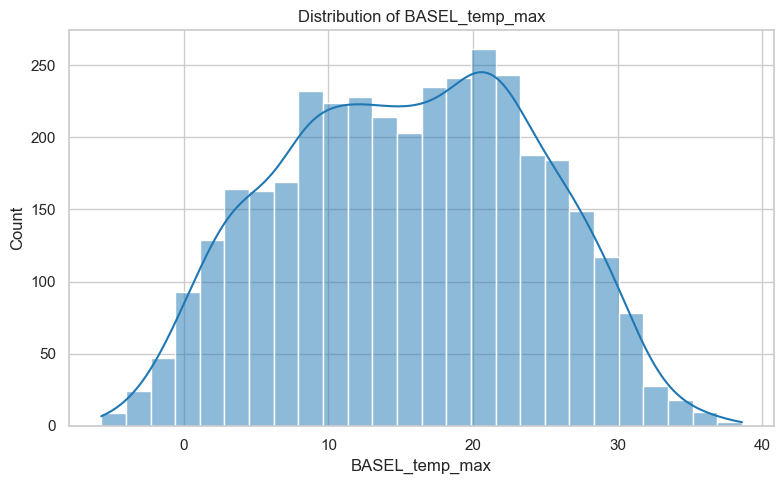

In [16]:
plt.figure(figsize=(8, 5))
sns.histplot(df['BASEL_temp_max'], kde=True, color='tab:blue')
plt.title('Distribution of BASEL_temp_max')
plt.xlabel('BASEL_temp_max')
plt.ylabel('Count')
plt.tight_layout()
plt.show()


### Graph 2: Class Distribution of `BASEL_BBQ_weather`


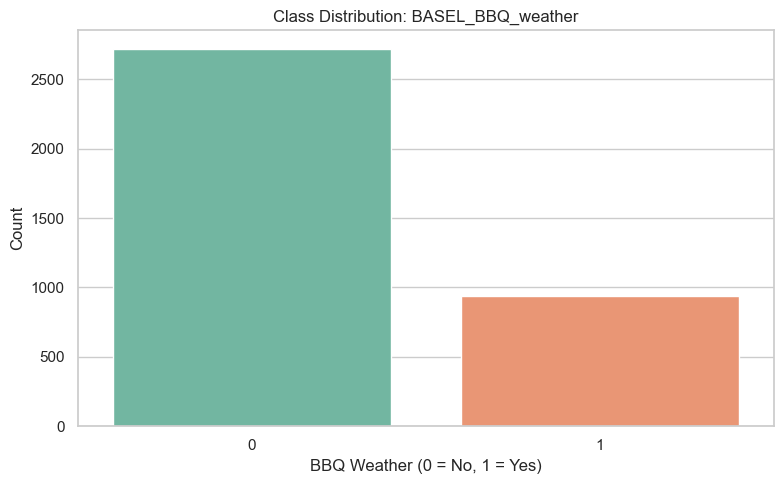

In [17]:
plt.figure(figsize=(8, 5))
sns.countplot(x='BASEL_BBQ_weather', data=df, palette='Set2')
plt.title('Class Distribution: BASEL_BBQ_weather')
plt.xlabel('BBQ Weather (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()


### Graph 3: Correlation Heatmap (Basel Features)


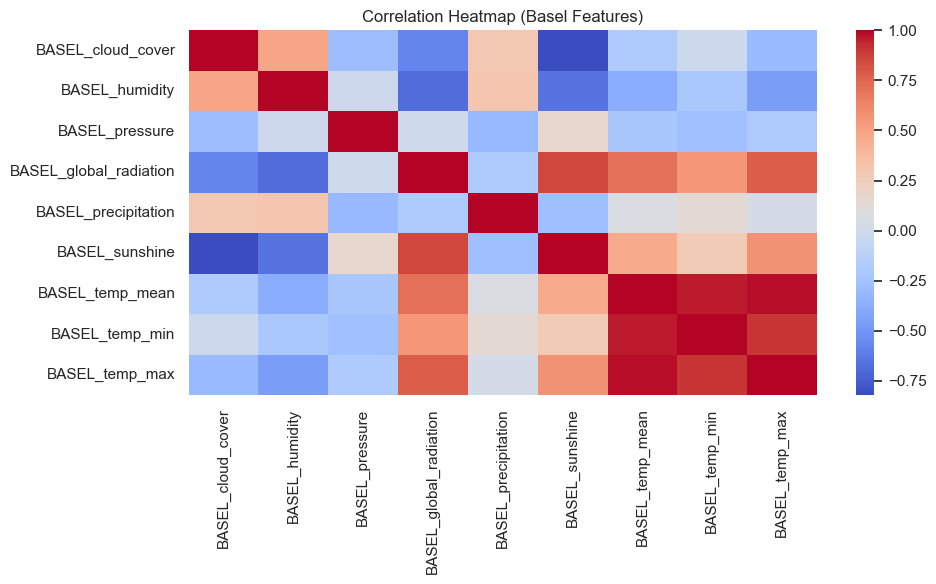

In [18]:
corr_cols = [
    'BASEL_cloud_cover',
    'BASEL_humidity',
    'BASEL_pressure',
    'BASEL_global_radiation',
    'BASEL_precipitation',
    'BASEL_sunshine',
    'BASEL_temp_mean',
    'BASEL_temp_min',
    'BASEL_temp_max',
]

plt.figure(figsize=(10, 6))
sns.heatmap(df[corr_cols].corr(), cmap='coolwarm', annot=False)
plt.title('Correlation Heatmap (Basel Features)')
plt.tight_layout()
plt.show()


In [19]:
# Outlier count using IQR rule (before modeling)
def iqr_outlier_count(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    return int(((series < lower) | (series > upper)).sum())

outlier_features = [
    'BASEL_cloud_cover',
    'BASEL_humidity',
    'BASEL_pressure',
    'BASEL_global_radiation',
    'BASEL_precipitation',
    'BASEL_sunshine',
    'BASEL_temp_mean',
    'BASEL_temp_min',
]

outlier_counts = pd.Series({col: iqr_outlier_count(df[col]) for col in outlier_features})
outlier_counts.sort_values(ascending=False)


BASEL_precipitation       536
BASEL_pressure             94
BASEL_humidity              9
BASEL_temp_min              3
BASEL_global_radiation      0
BASEL_cloud_cover           0
BASEL_sunshine              0
BASEL_temp_mean             0
dtype: int64

In [20]:
# Prepare data for modeling
feature_cols = [
    'MONTH',
    'season',
    'BASEL_cloud_cover',
    'BASEL_humidity',
    'BASEL_pressure',
    'BASEL_global_radiation',
    'BASEL_precipitation',
    'BASEL_sunshine',
    'BASEL_temp_mean',
    'BASEL_temp_min',
]

X = df[feature_cols].copy()
y_reg = df['BASEL_temp_max'].copy()
y_cls = df['BASEL_BBQ_weather'].copy()

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X, y_reg, test_size=0.2, random_state=42
)

X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(
    X, y_cls, test_size=0.2, random_state=42, stratify=y_cls
)

print('Regression split:', X_train_reg.shape, X_test_reg.shape)
print('Classification split:', X_train_cls.shape, X_test_cls.shape)
print('Classification target balance (train):')
print(y_train_cls.value_counts(normalize=True).rename('ratio'))


Regression split: (2923, 10) (731, 10)
Classification split: (2923, 10) (731, 10)
Classification target balance (train):
BASEL_BBQ_weather
0    0.743414
1    0.256586
Name: ratio, dtype: float64


In [21]:
# Custom transformer for outlier clipping (IQR capping)
class IQRClipper(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        x_df = pd.DataFrame(X)
        q1 = x_df.quantile(0.25)
        q3 = x_df.quantile(0.75)
        iqr = q3 - q1
        self.lower_ = q1 - 1.5 * iqr
        self.upper_ = q3 + 1.5 * iqr
        return self

    def transform(self, X):
        x_df = pd.DataFrame(X).copy()
        return x_df.clip(lower=self.lower_, upper=self.upper_, axis=1)


def build_preprocessor(numeric_features, categorical_features):
    numeric_pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('clipper', IQRClipper()),
        ('scaler', StandardScaler()),
    ])

    categorical_pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OneHotEncoder(handle_unknown='ignore')),
    ])

    return ColumnTransformer([
        ('num', numeric_pipeline, numeric_features),
        ('cat', categorical_pipeline, categorical_features),
    ])

numeric_features = [
    'MONTH',
    'BASEL_cloud_cover',
    'BASEL_humidity',
    'BASEL_pressure',
    'BASEL_global_radiation',
    'BASEL_precipitation',
    'BASEL_sunshine',
    'BASEL_temp_mean',
    'BASEL_temp_min',
]
categorical_features = ['season']


## 4. Model Building

### A. Linear Regression (for `BASEL_temp_max`)
### B. Logistic Regression (for `BASEL_BBQ_weather`)


In [22]:
# Linear Regression pipeline
linear_model = Pipeline([
    ('preprocessor', build_preprocessor(numeric_features, categorical_features)),
    ('model', LinearRegression()),
])

linear_model.fit(X_train_reg, y_train_reg)
y_pred_reg = linear_model.predict(X_test_reg)

r2 = r2_score(y_test_reg, y_pred_reg)
mse = mean_squared_error(y_test_reg, y_pred_reg)
rmse = np.sqrt(mse)

print('Linear Regression Metrics')
print(f'R^2  : {r2:.4f}')
print(f'MSE  : {mse:.4f}')
print(f'RMSE : {rmse:.4f}')


Linear Regression Metrics
R^2  : 0.9886
MSE  : 0.8542
RMSE : 0.9242


In [23]:
# Logistic Regression pipeline
logistic_model = Pipeline([
    ('preprocessor', build_preprocessor(numeric_features, categorical_features)),
    ('model', LogisticRegression(max_iter=2000)),
])

logistic_model.fit(X_train_cls, y_train_cls)
y_pred_cls = logistic_model.predict(X_test_cls)

acc = accuracy_score(y_test_cls, y_pred_cls)
prec = precision_score(y_test_cls, y_pred_cls, zero_division=0)
rec = recall_score(y_test_cls, y_pred_cls, zero_division=0)
cm = confusion_matrix(y_test_cls, y_pred_cls)

print('Logistic Regression Metrics')
print(f'Accuracy : {acc:.4f}')
print(f'Precision: {prec:.4f}')
print(f'Recall   : {rec:.4f}')
print('\nClassification Report:')
print(classification_report(y_test_cls, y_pred_cls, zero_division=0))


Logistic Regression Metrics
Accuracy : 0.9480
Precision: 0.8782
Recall   : 0.9251

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.96      0.96       544
           1       0.88      0.93      0.90       187

    accuracy                           0.95       731
   macro avg       0.93      0.94      0.93       731
weighted avg       0.95      0.95      0.95       731



### Graph 4: Confusion Matrix (Logistic Regression)


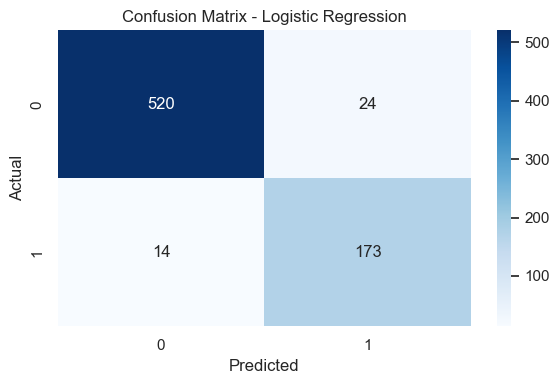

In [24]:
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Logistic Regression')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()


## 5. Model Evaluation Summary

Required metrics from the rubric:
- **Linear Regression**: R², MSE, RMSE
- **Logistic Regression**: Accuracy, Confusion Matrix, Precision, Recall


In [25]:
# Combined metric table
summary_df = pd.DataFrame([
    {'Model': 'Linear Regression', 'Metric': 'R^2', 'Value': r2},
    {'Model': 'Linear Regression', 'Metric': 'MSE', 'Value': mse},
    {'Model': 'Linear Regression', 'Metric': 'RMSE', 'Value': rmse},
    {'Model': 'Logistic Regression', 'Metric': 'Accuracy', 'Value': acc},
    {'Model': 'Logistic Regression', 'Metric': 'Precision', 'Value': prec},
    {'Model': 'Logistic Regression', 'Metric': 'Recall', 'Value': rec},
])
summary_df


,Model,Metric,Value
0,Linear Regression,R^2,0.988580
1,Linear Regression,MSE,0.854190
2,Linear Regression,RMSE,0.924224
3,Logistic Regression,Accuracy,0.948016
4,Logistic Regression,Precision,0.878173
5,Logistic Regression,Recall,0.925134


## 6. Interpretation & Conclusion

### Interpretation
The modeling results show that the selected Basel weather features capture strong signal for both tasks. The linear regression model achieves a high fit for `BASEL_temp_max`, which indicates that temperature behavior is well explained by humidity, pressure, radiation, precipitation, sunshine, and related variables. The logistic regression model also performs strongly, showing that these same weather patterns are useful for deciding whether a day is likely to be BBQ-friendly.

Key points:
- Regression performance is strong (`R^2` is high and errors are low), so the temperature prediction is reliable for this dataset.
- Classification metrics (accuracy, precision, recall) indicate balanced and practical detection of BBQ-weather days.
- Preprocessing improved consistency through missing-value checks, outlier handling, scaling, and categorical encoding.

### Conclusion
This project successfully completes the full weather prediction pipeline required in the rubric, from problem definition to final evaluation. Using real Kaggle data, we performed EDA, preprocessing, regression, classification, and metric-based validation. Overall, the models are effective, interpretable, and suitable as a complete final lab submission.

Final checklist:
- Problem definition and model justification included
- Real dataset and target variables clearly described
- EDA + preprocessing steps completed
- Linear Regression and Logistic Regression implemented
- Required evaluation metrics reported
- Interpretation and conclusion provided
